In [10]:
# statsbomb_shots.py
import json
import math
from pathlib import Path
import pandas as pd
import numpy as np
from nodes.utils import collect_all_shots, plot_shots
from nodes.model import SimpleXGModel
from nodes.plot import create_xg_heatmap, create_xg_heatmap_with_shots, compare_xg_by_technique
import matplotlib.pyplot as plt
import joblib


In [2]:
# import os

# # Go one level higher
# os.chdir("../..")

# # Check current directory
# print(os.getcwd())

### 1. Collect all shots

In [3]:
OPEN_DATA_DIR = Path("open-data/data")  # adjust if different
EVENTS_DIR = OPEN_DATA_DIR / "events"

In [ ]:
# shots_df = collect_all_shots(EVENTS_DIR)

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x121da5390>>
Traceback (most recent call last):
  File "/Users/rodrigo/football-data-analytics/.venv/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


In [ ]:
shots_df.shape

(88023, 16)

In [ ]:
# shots_df.to_csv("shots.csv", index=False)

### 2. Print some of them

In [6]:
shots_df.iloc[0]

match_id                                             None
event_id             943d24cf-3f41-41d0-81b9-c7237c374426
player_id                                           32119
player_name                                 Leandro Greco
team_id                                               226
team_name                                   Hellas Verona
minute                                                  9
second                                                 41
shot_outcome                                        Saved
shot_body_part                                  Left Foot
shot_technique                                Half Volley
x                                                    94.5
y                                                    54.5
dist_to_goal                                     29.33428
angle_to_goal_rad                                0.237022
angle_to_goal_deg                               13.580382
Name: 0, dtype: object

In [7]:
# fig, ax = plot_shots(shots_df, max_shots=10)
# plt.show()

In [8]:
# player_shots = shots_df[shots_df['player_name'] == 'Leandro Greco']
# fig, ax = plot_shots(player_shots)
# plt.show()

### 3. First model

In [4]:
shots_df=pd.read_csv("shots.csv")

In [6]:
shots_df.iloc[0]

match_id                                              NaN
event_id             943d24cf-3f41-41d0-81b9-c7237c374426
player_id                                           32119
player_name                                 Leandro Greco
team_id                                               226
team_name                                   Hellas Verona
minute                                                  9
second                                                 41
shot_outcome                                        Saved
shot_body_part                                  Left Foot
shot_technique                                Half Volley
x                                                    94.5
y                                                    54.5
dist_to_goal                                     29.33428
angle_to_goal_rad                                0.237022
angle_to_goal_deg                               13.580382
Name: 0, dtype: object

In [7]:
# 1. Create and train the model
xg_model = SimpleXGModel()
metrics = xg_model.train(shots_df)

MODEL TRAINING RESULTS
Accuracy: 0.8926
ROC AUC: 0.7926
Log Loss: 0.2884
Actual Goal Rate: 0.1112
Predicted Goal Rate: 0.1097

TOP 10 MOST IMPORTANT FEATURES:
--------------------------------------------------
technique_Backheel            : -1.5528
technique_Lob                 : +1.4516
bodypart_Head                 : -1.4103
technique_Overhead Kick       : -1.2583
technique_Diving Header       : +1.1250
bodypart_Other                : -0.7300
technique_Volley              : -0.6434
angle_to_goal                 : +0.6205
bodypart_Right Foot           : +0.5739
bodypart_Left Foot            : +0.4985
--------------------------------------------------


In [11]:
joblib.dump(xg_model, "simple_xg_model.joblib")
print("Model saved successfully!")

Model saved successfully!


### Analyze the dataframe

In [11]:
shots_df.head()

,match_id,event_id,player_id,player_name,team_id,team_name,minute,second,shot_outcome,shot_body_part,shot_technique,x,y,dist_to_goal,angle_to_goal_rad,angle_to_goal_deg
0,NaN,943d24cf-3f41-41d0-81b9-c7237c374426,32119,Leandro Greco,226,Hellas Verona,9,41,Saved,Left Foot,Half Volley,94.5,54.5,29.334280,0.237022,13.580382
1,NaN,579178b1-c0c2-4e83-ac0f-5004a1c9190a,11502,Antonio Di Gaudio,1683,Carpi,11,3,Off T,Right Foot,Normal,100.6,34.5,20.164573,0.378200,21.669273
2,NaN,ea2c07b1-d3f5-451a-acc8-09a0b8fd2fc7,7696,Ryder Matos Santos,1683,Carpi,14,56,Saved,Left Foot,Half Volley,108.3,47.0,13.634148,0.503568,28.852335
3,NaN,6cb60add-9332-4d3e-b1b7-40155584f2c9,6686,Giampaolo Pazzini,226,Hellas Verona,19,27,Blocked,Right Foot,Half Volley,108.1,34.3,13.194696,0.541999,31.054271
4,NaN,431384c7-9483-468f-b351-975f29bd7302,386651,Juan Ignacio Gómez Taleb,226,Hellas Verona,27,15,Saved,Right Foot,Normal,108.3,27.0,17.489711,0.312314,17.894287


In [12]:
shots_df['shot_outcome'].value_counts()

shot_outcome
Off T               28466
Blocked             21677
Saved               20788
Goal                 9790
Wayward              4823
Post                 1842
Saved Off Target      349
Saved to Post         288
Name: count, dtype: int64

In [13]:
goals_df=shots_df[shots_df['shot_outcome'] == 'Goal']

In [15]:
goals_df.player_name.value_counts().head(10)

player_name
Lionel Andrés Messi Cuccittini         510
Luis Alberto Suárez Díaz               140
Neymar da Silva Santos Junior           89
Samuel Eto''o Fils                      66
Kylian Mbappé Lottin                    64
Thierry Henry                           63
Vivianne Miedema                        59
Cristiano Ronaldo dos Santos Aveiro     59
Pedro Eliezer Rodríguez Ledesma         56
Zlatan Ibrahimović                      50
Name: count, dtype: int64

In [6]:
# 2. Add xG predictions to your dataframe
shots_with_xg = xg_model.add_xg_to_dataframe(shots_df)

In [7]:
# 3. Look at some predictions
print("\nSample predictions:")
shots_with_xg[['player_name', 'dist_to_goal', 'angle_to_goal_deg', 
                      'shot_outcome', 'xG']].head(10)


Sample predictions:


,player_name,dist_to_goal,angle_to_goal_deg,shot_outcome,xG
0,Leandro Greco,29.334280,13.580382,Saved,0.010915
1,Antonio Di Gaudio,20.164573,21.669273,Off T,0.099850
2,Ryder Matos Santos,13.634148,28.852335,Saved,0.109676
3,Giampaolo Pazzini,13.194696,31.054271,Blocked,0.135873
4,Juan Ignacio Gómez Taleb,17.489711,17.894287,Saved,0.089865
5,Leandro Greco,32.340841,12.990594,Saved,0.019265
6,Giampaolo Pazzini,17.928748,16.348908,Off T,0.031316
7,Jacopo Sala,26.335148,12.966080,Off T,0.028883
8,Antonio Di Gaudio,18.344754,16.935266,Saved,0.036440
9,Giampaolo Pazzini,9.740637,43.016783,Off T,0.098944


In [8]:
# 4. Analyze player performance
player_stats = shots_with_xg.groupby('player_name').agg({
    'xG': 'sum',
    'shot_outcome': lambda x: (x == 'Goal').sum()
}).reset_index()
player_stats.columns = ['player_name', 'total_xG', 'actual_goals']
player_stats['goals_minus_xG'] = player_stats['actual_goals'] - player_stats['total_xG']
player_stats = player_stats.sort_values('goals_minus_xG', ascending=False)
print("\nTop overperformers (Goals - xG):")
print(player_stats.head(10))


Top overperformers (Goals - xG):
                         player_name    total_xG  actual_goals  goals_minus_xG
3487  Lionel Andrés Messi Cuccittini  378.965650           510      131.034350
3596        Luis Alberto Suárez Díaz  106.197448           140       33.802552
3338            Kylian Mbappé Lottin   41.708005            64       22.291995
6066              Zlatan Ibrahimović   30.842124            50       19.157876
5634                   Thierry Henry   44.039123            63       18.960877
5201              Samuel Eto''o Fils   52.131037            66       13.868963
5081        Ronaldo de Assis Moreira   19.198524            33       13.801476
1974               Gareth Frank Bale   12.950580            25       12.049420
2225                      Harry Kane   32.141134            43       10.858866
4384   Neymar da Silva Santos Junior   78.162366            89       10.837634


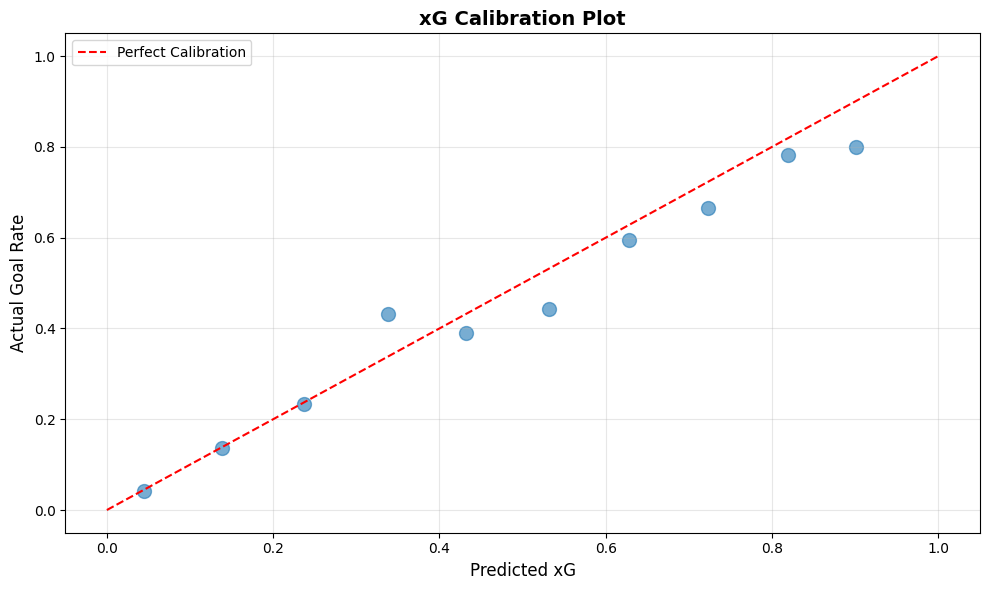

In [9]:
# 5. Plot calibration
xg_model.plot_xg_calibration(shots_df)

### 4. Plotting different stuff

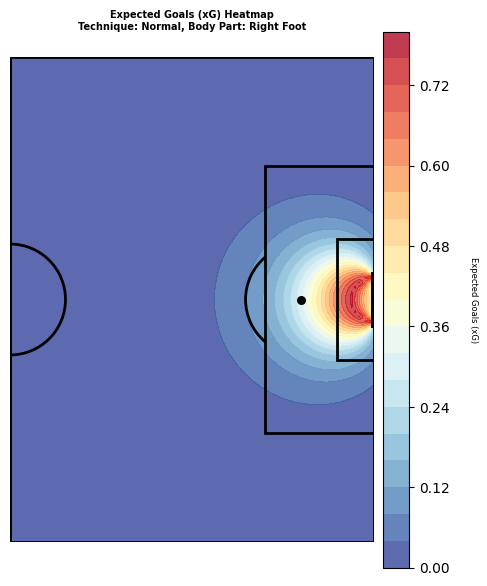

In [12]:
# # 1. Create basic xG heatmap
fig, ax = create_xg_heatmap(xg_model)
plt.show()

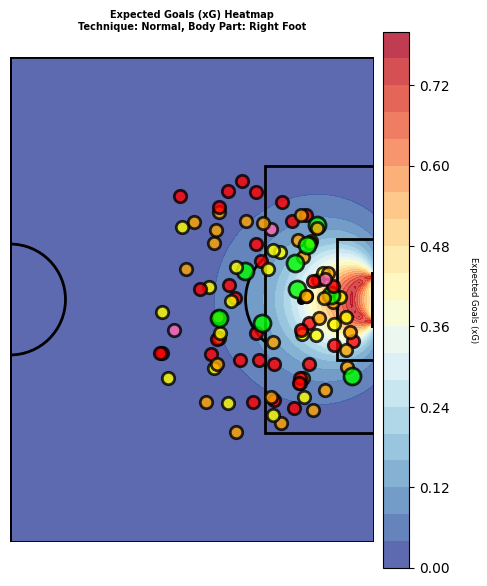

In [11]:
# 2. Create heatmap with actual shots overlaid
fig, ax = create_xg_heatmap_with_shots(xg_model, shots_df, max_shots=100)
plt.show()


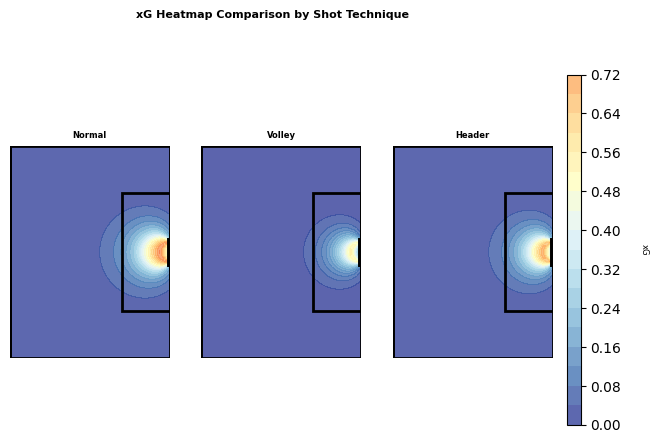

In [11]:
# 3. Compare different shot techniques
fig, axes = compare_xg_by_technique(xg_model, 
                                    techniques=['Normal', 'Volley', 'Header'])
plt.show()

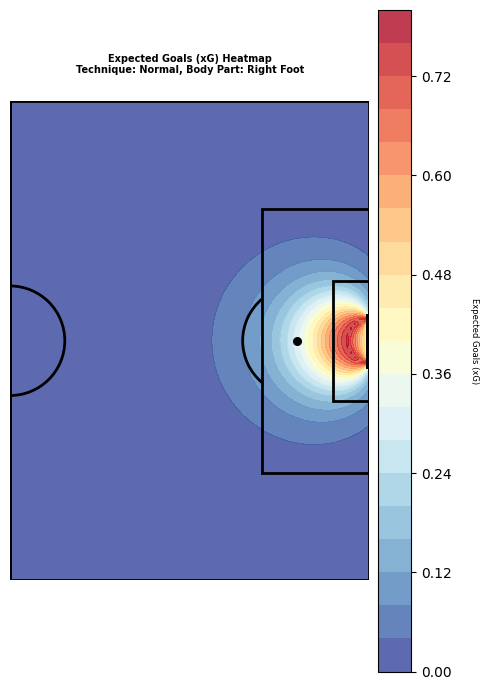

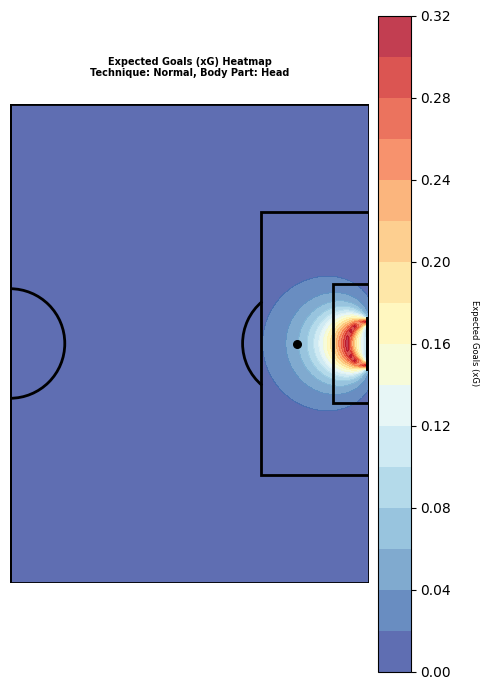

In [12]:
# 4. Compare body parts
fig, ax1 = create_xg_heatmap(xg_model, shot_body_part='Right Foot')
fig, ax2 = create_xg_heatmap(xg_model, shot_body_part='Head')
plt.show()